# Preliminaries

In [2]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation

import scipy.constants as const
from scipy.signal import fftconvolve, welch
import scipy.optimize as optimize

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [121]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

In [130]:
color_bg = "#08071F"
color_fg = "#ffffff"
lagrange_color = "#B3E2FF"
binary_color = "#FFF7B4"

# 1: Function Definitions

The following functions are for calculating the parameters of the Lagrange triple that give out the same waveform as that of a given binary system.

In [6]:
def findQuadDegeneracy_plus(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*(1 + (np.cos(i_3B))**2))/(1 + (np.cos(i_2B))**2)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "plus")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def findQuadDegeneracy_cross(a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B, beta_1, i_3B_deg, atol = 1e-23):
    #initialize binary
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    i_2B = np.radians(i_2B_deg)

    #free parameters of the Lagrange triple
    M_3B *= sol
    i_3B = np.radians(i_3B_deg)

    #parameters to solve
    r_3B = ((M_3B/binary.M_c)**(5/3))*(binary.r*beta_1*np.abs(3*beta_1 - 1)*np.cos(i_3B))/np.cos(i_2B)
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #find the appropriate integration constant Phi_c
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    for phi in shift:
        temp = [b/pc, M_3B*beta_1/sol, M_3B*beta_1/sol, M_3B*(1 - 2*beta_1)/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4] - lagrange.h_quad(t_max = 1, radRxn = True, pol = "cross")[:4])
            
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc, phi_3B

def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy_plus(params_binary, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_binary)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_binary[1]*sol + params_binary[2]*sol)/((params_binary[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_binary, beta_1)
        r_3B = find_r(*params_binary, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for true degeneracy.")


def octDegeneracy_cross_equations(init, params_binary, beta_1):
    #initial conditions must be in SI units (distances in [m], masses in [kg], angles in [rad])
    r_3B, M_3B, i_3B = init
    b1 = beta_1
    binary = waveforms.CircularBinary(*params_binary)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    eq1 = binary.h_quad(1, ampOnly = True, pol = "cross") - 4*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(3*b1 - 1)*np.cos(i_3B)/r_3B
    eq2 = binary.h_octcq(1, ampOnly = True, pol = "cross")[0] - (np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*(1 - 2*b1)*np.abs(3*b1 - 1)*np.sin(2*i_3B)/r_3B
    eq3 = binary.h_octcq(1, ampOnly = True, pol = "cross")[1] - (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*(1 - 2*b1)*np.sin(2*i_3B)/r_3B
    
    return [eq1, eq2, eq3]

def findOctDegeneracy_cross(init, a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, beta_1, method = "lm", root_tol = 1e-25, atol = 1e-23):
    binary = waveforms.CircularBinary(*[a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B])
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))
    
    #input initial conditions for root finding must be in pc and solar masses
    #r_3B in [m], M_3B in [kg], and i_3B in [rad]
    solved_params_3B = optimize.root(octDegeneracy_cross_equations, [init[0]*pc, init[1]*sol, np.radians(init[2])],
                            method = method, tol = root_tol, args = ([a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B], beta_1))
    print(solved_params_3B.message)
    r_3B, M_3B, i_3B = solved_params_3B.x
    b = (const.G*M_3B/(w_2B**2))**(1/3)
    m1_3B = M_3B*beta_1
    m3_3B = M_3B - 2*m1_3B
    i_3B_deg = np.degrees(i_3B)

    delta_t = 1/5000
    t_max = 3
    phi_3B = 0
    shift = np.linspace(0, 2*np.pi, 1000)
    
    for phi in shift:
        temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
        lagrange = waveforms.CircularLagrangeTriple(*temp)
        check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "cross")[:4])
                
        if all(np.isclose(check, 0, atol = atol)):
            phi_3B = phi
    
    return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]

In [226]:
def plot_waveform_transparent(params_2B, params_3B, t_max, delta_t, radRxn = True, filename = ""):
    #initialization
    binary = waveforms.CircularBinary(*params_2B)
    lagrange = waveforms.CircularLagrangeTriple(*params_3B)

    label_2B = "Binary"
    label_3B = "Lagrange"

    figsize = (15, 6)

    #create figure object and subfigure object
    fig, ((a1_p, a1_c), (a2_p, a2_c), (a3_p, a3_c)) = plt.subplots(nrows = 3, ncols = 2, gridspec_kw = {'height_ratios': [1, 1, 2], 'width_ratios': [1, 1]}, sharex = True, figsize = figsize)

    #set colors
    fig.patch.set_facecolor(color_bg)
    
    a1_p.set_facecolor(color_bg)
    a1_p.spines["bottom"].set_color(color_fg)
    a1_p.spines["top"].set_color(color_fg)
    a1_p.spines["right"].set_color(color_fg)
    a1_p.spines["left"].set_color(color_fg)
    a1_p.tick_params(axis = "x", colors = color_fg)
    a1_p.tick_params(axis = "y", colors = color_fg)
    a1_p.yaxis.label.set_color(color_fg)
    a1_p.xaxis.label.set_color(color_fg)

    a1_c.set_facecolor(color_bg)
    a1_c.spines["bottom"].set_color(color_fg)
    a1_c.spines["top"].set_color(color_fg)
    a1_c.spines["right"].set_color(color_fg)
    a1_c.spines["left"].set_color(color_fg)
    a1_c.tick_params(axis = "x", colors = color_fg)
    a1_c.tick_params(axis = "y", colors = color_fg)
    a1_c.yaxis.label.set_color(color_fg)
    a1_c.xaxis.label.set_color(color_fg)

    a2_p.set_facecolor(color_bg)
    a2_p.spines["bottom"].set_color(color_fg)
    a2_p.spines["top"].set_color(color_fg)
    a2_p.spines["right"].set_color(color_fg)
    a2_p.spines["left"].set_color(color_fg)
    a2_p.tick_params(axis = "x", colors = color_fg)
    a2_p.tick_params(axis = "y", colors = color_fg)
    a2_p.yaxis.label.set_color(color_fg)
    a2_p.xaxis.label.set_color(color_fg)

    a2_c.set_facecolor(color_bg)
    a2_c.spines["bottom"].set_color(color_fg)
    a2_c.spines["top"].set_color(color_fg)
    a2_c.spines["right"].set_color(color_fg)
    a2_c.spines["left"].set_color(color_fg)
    a2_c.tick_params(axis = "x", colors = color_fg)
    a2_c.tick_params(axis = "y", colors = color_fg)
    a2_c.yaxis.label.set_color(color_fg)
    a2_c.xaxis.label.set_color(color_fg)

    a3_p.set_facecolor(color_bg)
    a3_p.spines["bottom"].set_color(color_fg)
    a3_p.spines["top"].set_color(color_fg)
    a3_p.spines["right"].set_color(color_fg)
    a3_p.spines["left"].set_color(color_fg)
    a3_p.tick_params(axis = "x", colors = color_fg)
    a3_p.tick_params(axis = "y", colors = color_fg)
    a3_p.yaxis.label.set_color(color_fg)
    a3_p.xaxis.label.set_color(color_fg)

    a3_c.set_facecolor(color_bg)
    a3_c.spines["bottom"].set_color(color_fg)
    a3_c.spines["top"].set_color(color_fg)
    a3_c.spines["right"].set_color(color_fg)
    a3_c.spines["left"].set_color(color_fg)
    a3_c.tick_params(axis = "x", colors = color_fg)
    a3_c.tick_params(axis = "y", colors = color_fg)
    a3_c.yaxis.label.set_color(color_fg)
    a3_c.xaxis.label.set_color(color_fg)
    
    #plot the mass quadrupole waveforms
    a1_p.plot(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times,
                    lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus"),
                    ls = "solid", color = lagrange_color)
    a1_p.plot(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times,
                    binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus"),
                    ls = "dashed", color = binary_color)
    a1_p.set_ylabel(r"$h^{+}_{\mathrm{quad}}$", fontsize = "x-large")
    a1_c.plot(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times,
                    lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross"),
                    ls = "solid", color = lagrange_color)
    a1_c.plot(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times,
                    binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross"),
                    ls = "dashed", color = binary_color)
    a1_c.set_ylabel(r"$h^{\times}_{\mathrm{quad}}$", fontsize = "x-large")

    #plot the 0.5PN waveforms
    a2_p.plot(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times,
                    lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus"),
                    ls = "solid", color = lagrange_color)
    a2_p.plot(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times,
                    binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus"),
                    ls = "dashed", color = binary_color)
    a2_p.set_ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
    a2_c.plot(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times,
                    lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross"),
                    ls = "solid", color = lagrange_color)
    a2_c.plot(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times,
                    binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross"),
                    ls = "dashed", color = binary_color)
    a2_c.set_ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")

    #plot the combined waveform
    a3_p.plot(waveforms.h_combined3B(*params_3B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times,
                 waveforms.h_combined3B(*params_3B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0],
                 ls = "solid", color = lagrange_color, label = label_3B)
    a3_p.plot(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times,
                 waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0],
                 ls = "dashed", color = binary_color, label = label_2B)
    a3_p.set_ylabel(r"$h^{+}$", fontsize = "x-large")
    a3_c.plot(waveforms.h_combined3B(*params_3B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times,
                 waveforms.h_combined3B(*params_3B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1],
                 ls = "solid", color = lagrange_color, label = label_3B)
    a3_c.plot(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times,
                 waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1],
                 ls = "dashed", color = binary_color, label = label_2B)
    a3_c.set_ylabel(r"$h^{\times}$", fontsize = "x-large")

    a3_p.set_xlabel("Time, $t$ [s]", fontsize = "x-large")
    a3_c.set_xlabel("Time, $t$ [s]", fontsize = "x-large")

    a3_p.legend(facecolor = color_bg, labelcolor = color_fg, bbox_to_anchor = (0.15, -0.16))
    plt.tight_layout()

    #gridlines
    a1_p.grid()
    a1_p.set_axisbelow(True)
    a2_p.grid()
    a2_p.set_axisbelow(True)
    a3_p.grid()
    a3_p.set_axisbelow(True)
    
    a1_c.grid()
    a1_c.set_axisbelow(True)
    a2_c.grid()
    a2_c.set_axisbelow(True)
    a3_c.grid()
    a3_c.set_axisbelow(True)

    if not filename:
        pass
    else:
        plt.savefig(filename, bbox_inches = "tight", dpi = 1000, transparent = True)

# 2: Animated Plot of a Sample Binary Waveform

In [8]:
params_2B = [150e-13, 10, 8, 2e6, 30, 0]
binary = waveforms.CircularBinary(*params_2B)

print("Binary chirp mass in solar mass = {}".format(binary.M_c/sol))

Binary chirp mass in solar mass = 7.776774233174123


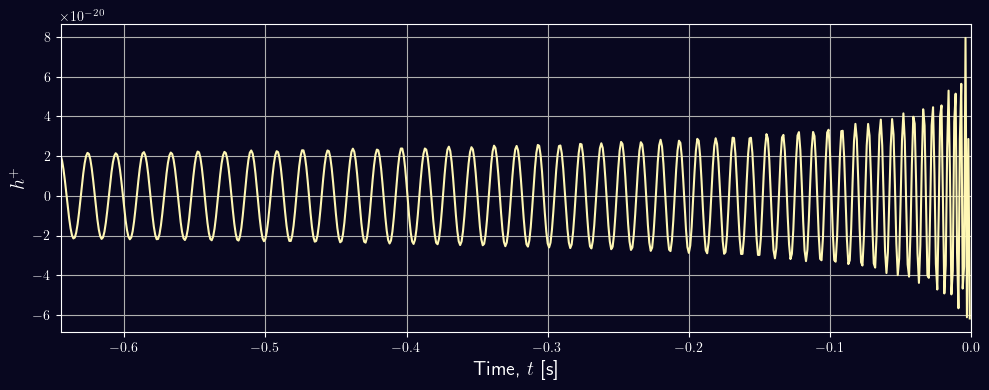

In [148]:
delta_t = 1/1000
t_max = 0.645

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)

fig, ax = plt.subplots(figsize = (10, 4))
ax.set_xlabel(r"Time, $t$ [s]", fontsize = "x-large")
ax.set_ylabel(r"$h^{+}$", fontsize = "x-large")

#color settings to match the BG of the video
fig.patch.set_facecolor(color_bg)
ax.set_facecolor(color_bg)
ax.spines["bottom"].set_color(color_fg)
ax.spines["top"].set_color(color_fg)
ax.spines["right"].set_color(color_fg)
ax.spines["left"].set_color(color_fg)
ax.tick_params(axis = "x", colors = color_fg)
ax.tick_params(axis = "y", colors = color_fg)
ax.yaxis.label.set_color(color_fg)
ax.xaxis.label.set_color(color_fg)

#set axis limits
ax.set_xlim(-0.645, 0)
ax.grid(True)
ax.set_axisbelow(True)

artists = []
for i in range(len(hp_2B.sample_times)):
    sampleBinary_plus = ax.plot(hp_2B.sample_times[:i + 1], hp_2B[:i + 1], color = "#FFF7B4")
    artists.append(sampleBinary_plus)

plt.tight_layout()

ani = animation.ArtistAnimation(fig = fig, artists = artists, interval = 20)
ani.save(filename = "Animations/Sample Binary (Plus).mp4", writer = "ffmpeg", dpi = 300, savefig_kwargs = {"transparent": True})
plt.show()

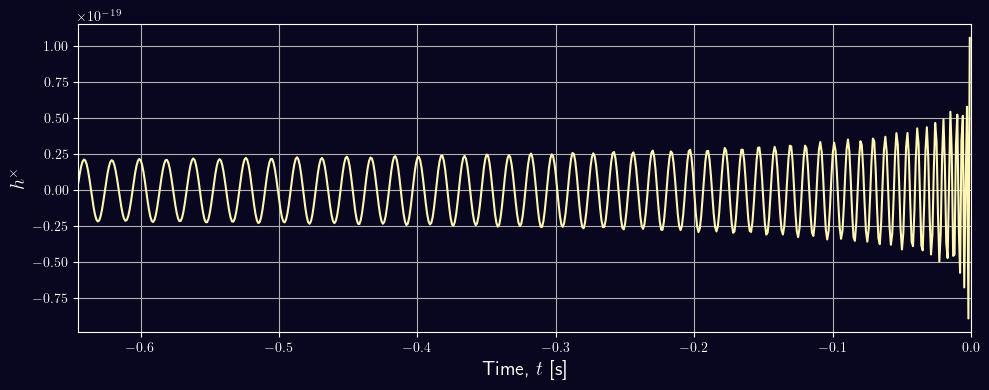

In [152]:
delta_t = 1/1000
t_max = 0.645

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)

fig, ax = plt.subplots(figsize = (10, 4))
ax.set_xlabel(r"Time, $t$ [s]", fontsize = "x-large")
ax.set_ylabel(r"$h^{\times}$", fontsize = "x-large")

#color settings to match the BG of the video
fig.patch.set_facecolor(color_bg)
ax.set_facecolor(color_bg)
ax.spines["bottom"].set_color(color_fg)
ax.spines["top"].set_color(color_fg)
ax.spines["right"].set_color(color_fg)
ax.spines["left"].set_color(color_fg)
ax.tick_params(axis = "x", colors = color_fg)
ax.tick_params(axis = "y", colors = color_fg)
ax.yaxis.label.set_color(color_fg)
ax.xaxis.label.set_color(color_fg)

#set axis limits
ax.set_xlim(-0.645, 0)
ax.grid(True)
ax.set_axisbelow(True)

artists = []
for i in range(len(hc_2B.sample_times)):
    sampleBinary_cross = ax.plot(hc_2B.sample_times[:i + 1], hc_2B[:i + 1], color = "#FFF7B4")
    artists.append(sampleBinary_cross)

plt.tight_layout()

ani = animation.ArtistAnimation(fig = fig, artists = artists, interval = 20)
ani.save(filename = "Animations/Sample Binary (Cross).mp4", writer = "ffmpeg", dpi = 300, savefig_kwargs = {"transparent": True})
plt.show()

# 3: Transparent and Color-Adjusted Waveform Plots

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


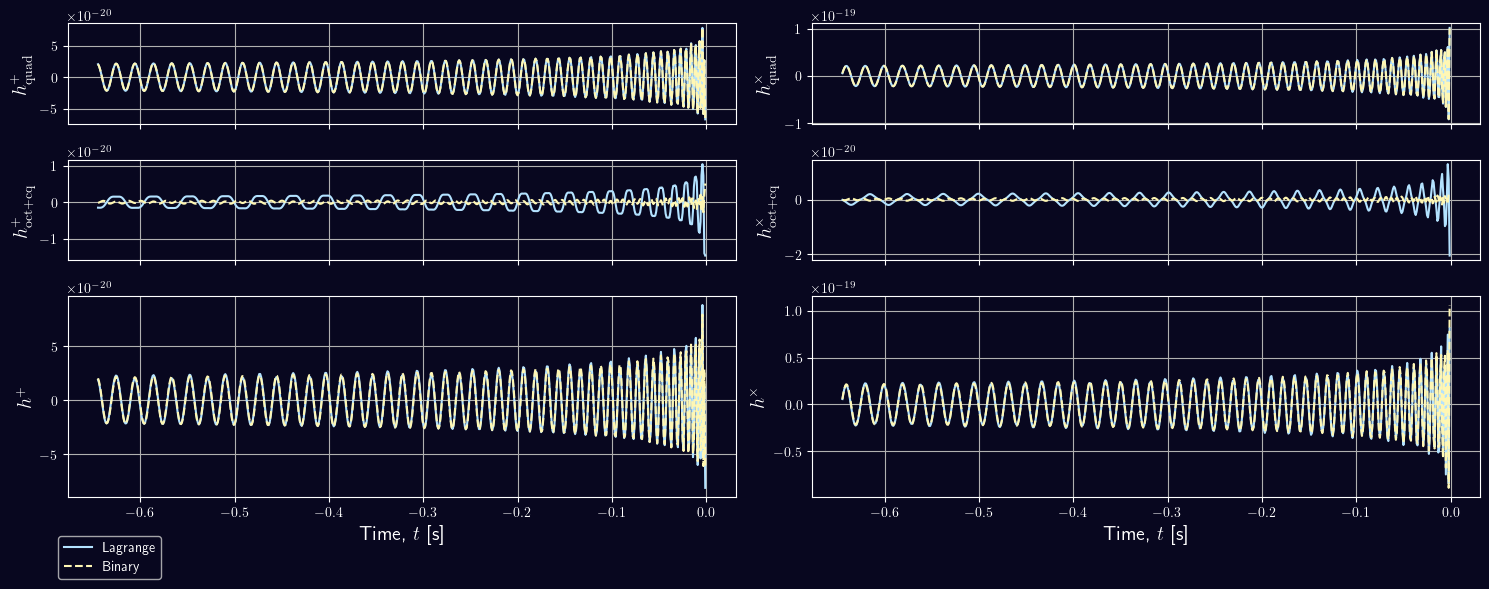

In [228]:
delta_t = 1/1000
t_max = 0.645

M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 15
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad4, t_max = t_max, delta_t = delta_t)

plot_waveform_transparent(params_2B, params_3B_quad4, t_max = t_max, delta_t = delta_t, radRxn = True,
                          filename = "Animations/MQ Degeneracy.png")

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_80731/3441334345.py:61: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_80731/3441334345.py:64: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_80731/3441334345.py:64: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.

Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


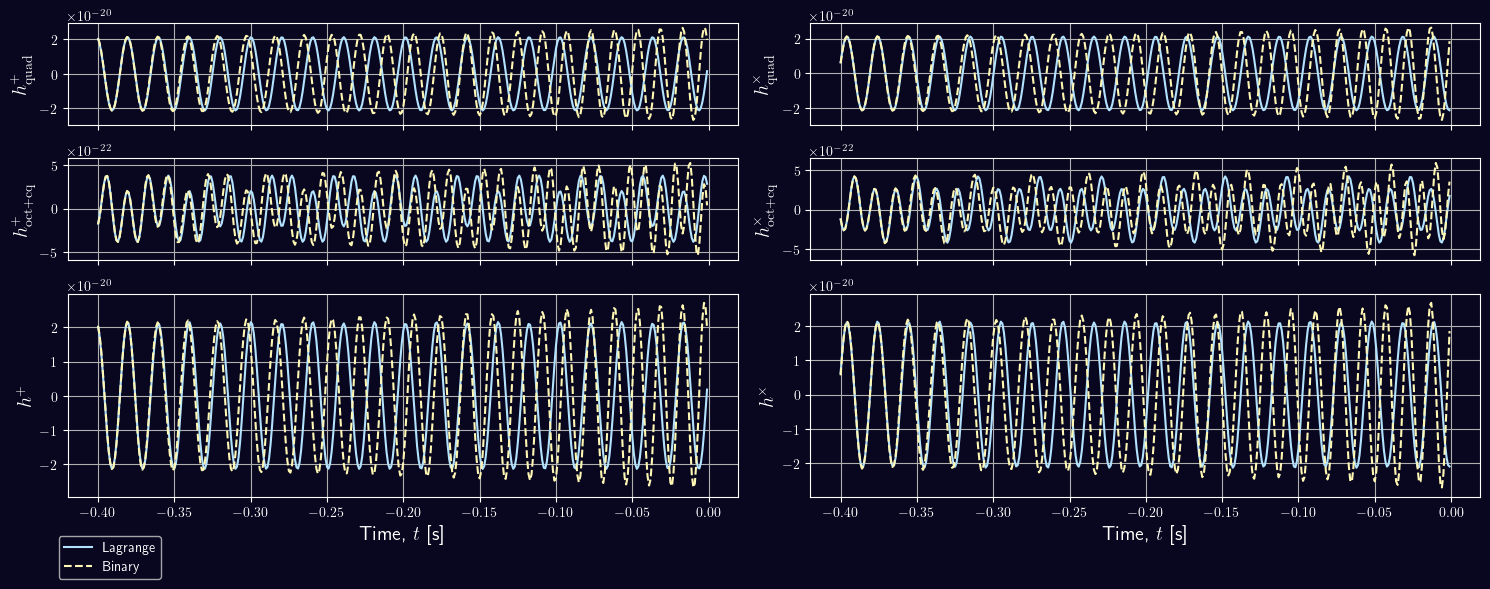

In [236]:
delta_t = 1/1000
t_max = 0.4

M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

params_3B_oct1 = findOctDegeneracy_plus(params_2B, 1/6)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

plot_waveform_transparent(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                          filename = "Animations/0.5PN Degeneracy.png")

# 4: Animated Waveform Degeneracy

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_80731/3441334345.py:61: R

Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


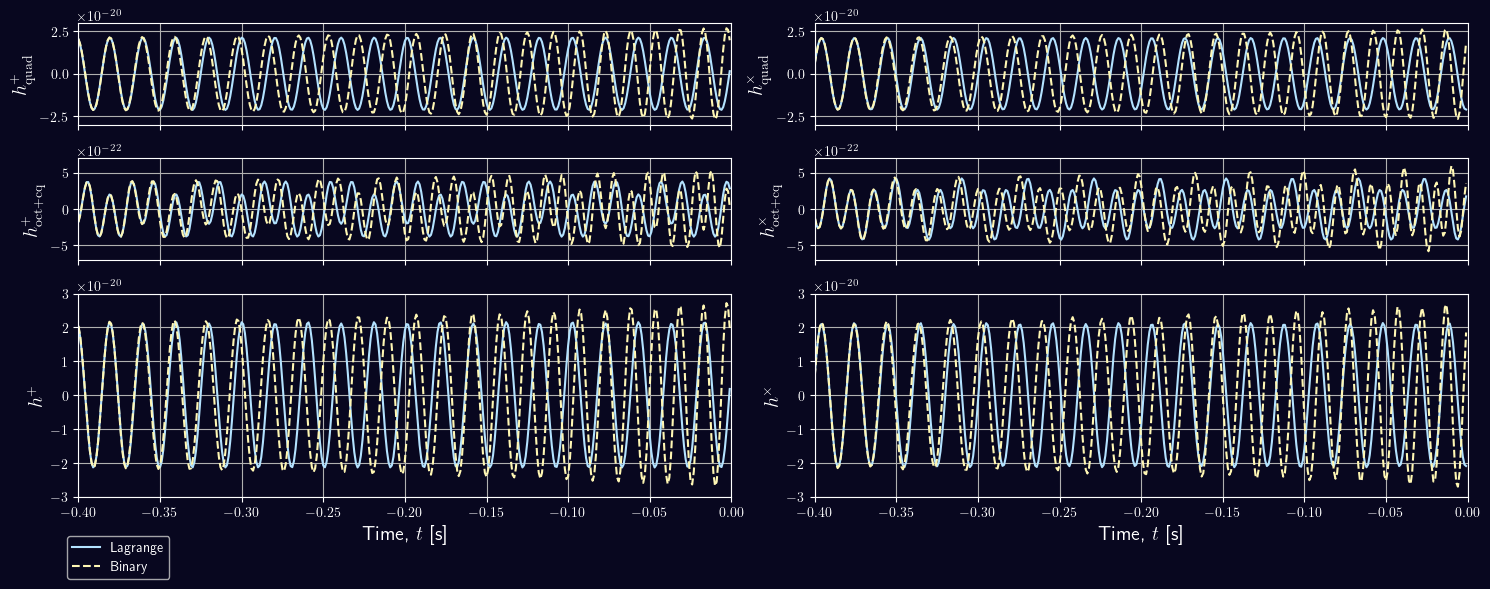

In [223]:
#solve for the parameters for MQ degeneracy
delta_t = 1/1000
t_max = 0.4

M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
i_3B = 15
quad_result = findQuadDegeneracy_plus(*params_2B[:5], M_3B, beta_1, i_3B, atol = 1e-22)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], i_3B, quad_result[2]]
params_3B_oct_plus1 = findOctDegeneracy_plus(params_2B, 1/6)

#initialize the binary and the Lagrange triple
binary = waveforms.CircularBinary(*params_2B)
lagrange = waveforms.CircularLagrangeTriple(*params_3B_oct_plus1)
radRxn = True

#figure labels
label_2B = "Binary"
label_3B = "Lagrange"

#set figsize
figsize = (15, 6)

#create figure object and subfigure object
fig, ((a1_p, a1_c), (a2_p, a2_c), (a3_p, a3_c)) = plt.subplots(nrows = 3, ncols = 2, gridspec_kw = {'height_ratios': [1, 1, 2], 'width_ratios': [1, 1]}, sharex = True, figsize = figsize)

#set colors and axis limits
fig.patch.set_facecolor(color_bg)
    
a1_p.set_facecolor(color_bg)
a1_p.spines["bottom"].set_color(color_fg)
a1_p.spines["top"].set_color(color_fg)
a1_p.spines["right"].set_color(color_fg)
a1_p.spines["left"].set_color(color_fg)
a1_p.tick_params(axis = "x", colors = color_fg)
a1_p.tick_params(axis = "y", colors = color_fg)
a1_p.yaxis.label.set_color(color_fg)
a1_p.xaxis.label.set_color(color_fg)
a1_p.set_xlim(-t_max, 0)
a1_p.set_ylim(-3e-20, 3e-20)

a1_c.set_facecolor(color_bg)
a1_c.spines["bottom"].set_color(color_fg)
a1_c.spines["top"].set_color(color_fg)
a1_c.spines["right"].set_color(color_fg)
a1_c.spines["left"].set_color(color_fg)
a1_c.tick_params(axis = "x", colors = color_fg)
a1_c.tick_params(axis = "y", colors = color_fg)
a1_c.yaxis.label.set_color(color_fg)
a1_c.xaxis.label.set_color(color_fg)
a1_c.set_xlim(-t_max, 0)
a1_c.set_ylim(-3e-20, 3e-20)

a2_p.set_facecolor(color_bg)
a2_p.spines["bottom"].set_color(color_fg)
a2_p.spines["top"].set_color(color_fg)
a2_p.spines["right"].set_color(color_fg)
a2_p.spines["left"].set_color(color_fg)
a2_p.tick_params(axis = "x", colors = color_fg)
a2_p.tick_params(axis = "y", colors = color_fg)
a2_p.yaxis.label.set_color(color_fg)
a2_p.xaxis.label.set_color(color_fg)
a2_p.set_xlim(-t_max, 0)
a2_p.set_ylim(-7e-22, 7e-22)

a2_c.set_facecolor(color_bg)
a2_c.spines["bottom"].set_color(color_fg)
a2_c.spines["top"].set_color(color_fg)
a2_c.spines["right"].set_color(color_fg)
a2_c.spines["left"].set_color(color_fg)
a2_c.tick_params(axis = "x", colors = color_fg)
a2_c.tick_params(axis = "y", colors = color_fg)
a2_c.yaxis.label.set_color(color_fg)
a2_c.xaxis.label.set_color(color_fg)
a2_c.set_xlim(-t_max, 0)
a2_c.set_ylim(-7e-22, 7e-22)

a3_p.set_facecolor(color_bg)
a3_p.spines["bottom"].set_color(color_fg)
a3_p.spines["top"].set_color(color_fg)
a3_p.spines["right"].set_color(color_fg)
a3_p.spines["left"].set_color(color_fg)
a3_p.tick_params(axis = "x", colors = color_fg)
a3_p.tick_params(axis = "y", colors = color_fg)
a3_p.yaxis.label.set_color(color_fg)
a3_p.xaxis.label.set_color(color_fg)
a3_p.set_xlim(-t_max, 0)
a3_p.set_ylim(-3e-20, 3e-20)
    
a3_c.set_facecolor(color_bg)
a3_c.spines["bottom"].set_color(color_fg)
a3_c.spines["top"].set_color(color_fg)
a3_c.spines["right"].set_color(color_fg)
a3_c.spines["left"].set_color(color_fg)
a3_c.tick_params(axis = "x", colors = color_fg)
a3_c.tick_params(axis = "y", colors = color_fg)
a3_c.yaxis.label.set_color(color_fg)
a3_c.xaxis.label.set_color(color_fg)
a3_c.set_xlim(-t_max, 0)
a3_c.set_ylim(-3e-20, 3e-20)

#gridlines
a1_p.grid()
a1_p.set_axisbelow(True)
a2_p.grid()
a2_p.set_axisbelow(True)
a3_p.grid()
a3_p.set_axisbelow(True)
    
a1_c.grid()
a1_c.set_axisbelow(True)
a2_c.grid()
a2_c.set_axisbelow(True)
a3_c.grid()
a3_c.set_axisbelow(True)

#plot the mass quadrupole waveforms
h_mq_3B_p, = a1_p.plot(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[0],
                lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[0],
                ls = "solid", color = lagrange_color)
h_mq_2B_p, = a1_p.plot(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[0],
                binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[0],
                ls = "dashed", color = binary_color)
h_mq_3B_c, = a1_c.plot(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[0],
                lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[0],
                ls = "solid", color = lagrange_color)
h_mq_2B_c, = a1_c.plot(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[0],
                binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[0],
                ls = "dashed", color = binary_color)

#plot the 0.5PN waveforms
h_oct_3B_p, = a2_p.plot(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[0],
                    lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[0],
                    ls = "solid", color = lagrange_color)
h_oct_2B_p, = a2_p.plot(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[0],
                binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[0],
                ls = "dashed", color = binary_color)
    
h_oct_3B_c, = a2_c.plot(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[0],
                lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[0],
                ls = "solid", color = lagrange_color)
h_oct_2B_c, = a2_c.plot(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[0],
                binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[0],
                ls = "dashed", color = binary_color)

#plot the combined waveform
h_3B_p, = a3_p.plot(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times[0],
             waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0][0],
             ls = "solid", color = lagrange_color, label = label_3B)
h_2B_p, = a3_p.plot(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times[0],
             waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0][0],
             ls = "dashed", color = binary_color, label = label_2B)
h_3B_c, = a3_c.plot(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times[0],
             waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1][0],
             ls = "solid", color = lagrange_color, label = label_3B)
h_2B_c, = a3_c.plot(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times[0],
             waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1][0],
             ls = "dashed", color = binary_color, label = label_2B)

#set the y-label
a1_p.set_ylabel(r"$h^{+}_{\mathrm{quad}}$", fontsize = "x-large")
a1_c.set_ylabel(r"$h^{\times}_{\mathrm{quad}}$", fontsize = "x-large")

a2_p.set_ylabel(r"$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")
a2_c.set_ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")

a3_p.set_ylabel(r"$h^{+}$", fontsize = "x-large")
a3_c.set_ylabel(r"$h^{\times}$", fontsize = "x-large")

#set the x-label
a3_p.set_xlabel("Time, $t$ [s]", fontsize = "x-large")
a3_c.set_xlabel("Time, $t$ [s]", fontsize = "x-large")

#legend
a3_p.legend(facecolor = color_bg, labelcolor = color_fg, bbox_to_anchor = (0.15, -0.16))

def animate_waveform(i):
    #update the mass quadrupole waveforms
    h_mq_3B_p.set_xdata(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[:i + 1])
    h_mq_3B_p.set_ydata(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[:i + 1])
    
    h_mq_2B_p.set_xdata(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[:i + 1])
    h_mq_2B_p.set_ydata(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[:i + 1])
    
    h_mq_3B_c.set_xdata(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[:i + 1])
    h_mq_3B_c.set_ydata(lagrange.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[:i + 1])
    
    h_mq_2B_c.set_xdata(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[:i + 1])
    h_mq_2B_c.set_ydata(binary.h_quad(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[:i + 1])
    
    #update the 0.5PN waveforms
    h_oct_3B_p.set_xdata(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[:i + 1])
    h_oct_3B_p.set_ydata(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[:i + 1])
    
    h_oct_2B_p.set_xdata(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus").sample_times[:i + 1])
    h_oct_2B_p.set_ydata(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "plus")[:i + 1])
    
    h_oct_3B_c.set_xdata(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[:i + 1])
    h_oct_3B_c.set_ydata(lagrange.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[:i + 1])
    
    h_oct_2B_c.set_xdata(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross").sample_times[:i + 1])
    h_oct_2B_c.set_ydata(binary.h_octcq(t_max = t_max, delta_t = delta_t, radRxn = radRxn, pol = "cross")[:i + 1])

    #update the total waveform
    h_3B_p.set_xdata(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times[:i + 1])
    h_3B_p.set_ydata(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0][:i + 1])
    
    h_2B_p.set_xdata(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0].sample_times[:i + 1])
    h_2B_p.set_ydata(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[0][:i + 1])
    
    h_3B_c.set_xdata(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times[:i + 1])
    h_3B_c.set_ydata(waveforms.h_combined3B(*params_3B_oct_plus1, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1][:i + 1])
    
    h_2B_c.set_xdata(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1].sample_times[:i + 1])
    h_2B_c.set_ydata(waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t, radRxn = radRxn)[1][:i + 1])

    return (h_mq_3B_p, h_mq_2B_p, h_mq_3B_c, h_mq_2B_c, h_oct_3B_p, h_oct_2B_p, h_oct_3B_c, h_oct_2B_c, h_3B_p, h_2B_p, h_3B_c, h_2B_c)

plt.tight_layout()
ani = animation.FuncAnimation(fig = fig, func = animate_waveform, frames = int(t_max/delta_t), interval = 20, blit = True)
ani.save(filename = "Animations/0.5PN Degeneracy 1.mp4", writer = "ffmpeg", dpi = 300)
plt.show()